<a href="https://colab.research.google.com/github/carn51/Assignment-1/blob/main/unified3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [229]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import operator as op

In [230]:
df = pd.DataFrame(pd.read_csv('/content/UnifiedDataset.csv'))#.dropna(subset = 'Life Expectancy')

In [231]:
high_missingness_columns = [col for col in df.columns if ((df[col].isnull().sum()/ len(df.index)) < 0.75)]
high_missingness_data = df.drop(columns = high_missingness_columns)

In [232]:
df = df[df['Year'] > 2010]
df = df[df['Gender'] == 'Both sexes']

In [233]:
#keep for later comparison
female_data = df[df['Gender'] == 'Female']
male_data = df[df['Gender'] == 'Male']

In [234]:
#.items zips index and value
tracker = list(df['Country'].items())
tracker

[(63, 'Afghanistan'),
 (66, 'Afghanistan'),
 (69, 'Afghanistan'),
 (72, 'Afghanistan'),
 (75, 'Afghanistan'),
 (78, 'Afghanistan'),
 (81, 'Afghanistan'),
 (84, 'Afghanistan'),
 (87, 'Afghanistan'),
 (153, 'Africa'),
 (156, 'Africa'),
 (159, 'Africa'),
 (162, 'Africa'),
 (165, 'Africa'),
 (168, 'Africa'),
 (171, 'Africa'),
 (174, 'Africa'),
 (177, 'Africa'),
 (243, 'Albania'),
 (246, 'Albania'),
 (249, 'Albania'),
 (252, 'Albania'),
 (255, 'Albania'),
 (258, 'Albania'),
 (261, 'Albania'),
 (264, 'Albania'),
 (267, 'Albania'),
 (333, 'Algeria'),
 (336, 'Algeria'),
 (339, 'Algeria'),
 (342, 'Algeria'),
 (345, 'Algeria'),
 (348, 'Algeria'),
 (351, 'Algeria'),
 (354, 'Algeria'),
 (357, 'Algeria'),
 (381, 'American Samoa'),
 (382, 'American Samoa'),
 (383, 'American Samoa'),
 (384, 'American Samoa'),
 (385, 'American Samoa'),
 (386, 'American Samoa'),
 (387, 'American Samoa'),
 (388, 'American Samoa'),
 (389, 'American Samoa'),
 (411, 'Americas'),
 (412, 'Americas'),
 (413, 'Americas'),
 (41

In [235]:
df = df.drop(columns = ['Country', 'Gender'])
df.head(3)

,Year,Life Expectancy,Infant Mortality Rate,Low CI Value Infant Mortality Rate,High CI Value Infant Mortality Rate,Under 5 Mortality Rate,Low CI Value Under 5 Mortality Rate,High CI Value Under 5 Mortality Rate,% Death Cardiovascular,Low CI Value % Death Cardiovascular,...,Cereal Consumption Rye,Cereal Consumption Barley,Cereal Consumption Sorghum,Cereal Consumption Maize,Cereal Consumption Wheat,Cereal Consumption Rice,Diet Calories Animal Protein,Diet Calories Plant Protein,Diet Calories Fat,Diet Calories Carbohydrates
63,2011,61.553,61.73,56.92,67.09,83.91,76.35,92.32,37.1,22.8,...,NaN,22.0,NaN,21.0,1383.0,167.0,48.72,186.92,297.72,1573.64
66,2012,62.054,59.45,54.35,65.03,80.34,72.31,89.08,36.6,22.4,...,NaN,23.0,NaN,22.0,1378.0,146.0,49.04,186.60,300.33,1564.03
69,2013,62.525,57.23,51.91,63.11,76.83,68.48,86.08,36.2,22.1,...,NaN,26.0,NaN,21.0,1369.0,141.0,48.88,184.12,301.68,1555.32


In [236]:
def partial_col_search(df, string):
  #returns list of columns not data
  return [col for col in df.columns if op.contains(col, string)]

In [237]:
#substrings of ...
partial_strings_to_drop = ['High CI', 'Low CI', 'Consumption', 'Calories', 'Composition', 'Hand Washing']
colnames_to_drop = []
for partial_string in partial_strings_to_drop:
  #extend adds to one list to avoid creating so many lists
  colnames_to_drop.extend(partial_col_search(df, partial_string))
df = df.drop(columns = colnames_to_drop)

In [238]:
df.columns

Index(['Year', 'Life Expectancy', 'Infant Mortality Rate',
       'Under 5 Mortality Rate', '% Death Cardiovascular', 'Suicides Rate',
       'Alcohol Abuse', 'Air Pollution Death Rate Stroke',
       'Air Pollution Death Rate Stroke Age Standarized',
       'Air Pollution Death Rate Ischaemic Heart Disease',
       'Air Pollution Death Rate Ischaemic Heart Disease Age Standarized',
       'Air Pollution Death Rate Lower Respiratory Infections',
       'Air Pollution Death Rate Lower Respiratory Infections Age Standarized',
       'Air Pollution Death Rate Chronic Obstructive Pulmonary Disease',
       'Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized',
       'Air Pollution Death Rate Total',
       'Air Pollution Death Rate Total Age Standarized',
       'Air Pollution Death Rate Trachea Bronchus Lung Cancers',
       'Air Pollution Death Rate Trachea Bronchus Lung Cancers Age Standarized',
       'Unsafe Wash Mortality Rate', 'Poisoning Mortality Rate',

In [239]:
#hand pick columns
df = df[['Life Expectancy', 'Infant Mortality Rate',
         'Conflict and Terrorism Deaths', 'Homicide Rate',
         '% Injury Deaths', 'Death Rate', 'Birth Rate', 'Battle Related Deaths',
         '% Population $1.90 a day', '% Population $3.20 a day',
         '% Population $5.50 a day', 'Income per Capita', 'Total Population']]

In [240]:
#df = df.dropna()

In [241]:
df.isnull().sum()

,0
Life Expectancy,0
Infant Mortality Rate,675
Conflict and Terrorism Deaths,1029
Homicide Rate,808
% Injury Deaths,1831
Death Rate,642
Birth Rate,644
Battle Related Deaths,1898
% Population $1.90 a day,1639
% Population $3.20 a day,1639


Prep --> pca --> plot scatter

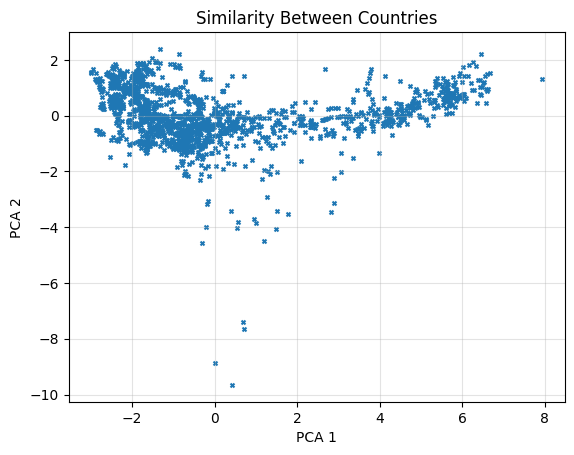

In [242]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split

#first pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer()),
    ('pca', PCA(n_components=2))
])

#split
X = df.drop(columns = ['Life Expectancy'])
y = df['Life Expectancy']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=23, train_size = .8)

#train
pca_cols = pipeline.fit_transform(X_train, y_train)

#extract
pca_df = pd.DataFrame(pca_cols)

#plot
plt.title('Similarity Between Countries')
plt.scatter(pca_df[0], pca_df[1], s = 8, marker= 'x')
plt.grid(alpha = 0.35)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

DBSCAN

In [269]:
from sklearn.cluster import DBSCAN

pipeline_dbscan = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer()),
    ('pca', PCA(n_components=2)),
    ('dbscan', DBSCAN(eps = 0.3, min_samples = 20))#= int(np.floor(len(df.index) / 100))))
])

pipeline_dbscan.fit(X_train, y_train)
pipeline_dbscan_result = pipeline_dbscan.named_steps['dbscan'].labels_
print(pipeline_dbscan_result)

tracker_results = zip(pipeline_dbscan_result, tracker)
print(list(tracker_results))

[0 0 0 ... 0 0 1]
[(np.int64(0), (63, 'Afghanistan')), (np.int64(0), (66, 'Afghanistan')), (np.int64(0), (69, 'Afghanistan')), (np.int64(-1), (72, 'Afghanistan')), (np.int64(0), (75, 'Afghanistan')), (np.int64(0), (78, 'Afghanistan')), (np.int64(0), (81, 'Afghanistan')), (np.int64(0), (84, 'Afghanistan')), (np.int64(2), (87, 'Afghanistan')), (np.int64(0), (153, 'Africa')), (np.int64(-1), (156, 'Africa')), (np.int64(0), (159, 'Africa')), (np.int64(-1), (162, 'Africa')), (np.int64(-1), (165, 'Africa')), (np.int64(0), (168, 'Africa')), (np.int64(0), (171, 'Africa')), (np.int64(0), (174, 'Africa')), (np.int64(-1), (177, 'Africa')), (np.int64(-1), (243, 'Albania')), (np.int64(0), (246, 'Albania')), (np.int64(0), (249, 'Albania')), (np.int64(0), (252, 'Albania')), (np.int64(-1), (255, 'Albania')), (np.int64(0), (258, 'Albania')), (np.int64(0), (261, 'Albania')), (np.int64(0), (264, 'Albania')), (np.int64(0), (267, 'Albania')), (np.int64(0), (333, 'Algeria')), (np.int64(0), (336, 'Algeria')),

In [270]:
#AI code
# Re-creating tracker_results as a list since it was consumed in the previous cell
# pipeline_dbscan_result and tracker are available in the kernel state
tracker_results = list(zip(pipeline_dbscan_result, tracker))

clusters = {}
for label, (original_index, country_name) in tracker_results:
    if label not in clusters:
        clusters[label] = []
    clusters[label].append(country_name)

# Display the clusters
for label, countries in clusters.items():
    print(f"Cluster {label}: {len(countries)} countries")
    print(set(countries)) # Print first 5 countries for brevity

Cluster 0: 1292 countries
{'Guam', 'Macao', 'Monaco', 'Kyrgyzstan', 'American Samoa', 'Saint Helena', 'Iran', 'Cameroon', 'Saudi Arabia', 'Kenya', 'Moldova', 'Myanmar', 'Nepal', 'Chad', 'Romania', 'Bonaire Sint Eustatius and Saba', 'Bermuda', 'British Virgin Islands', 'Greece', 'Bulgaria', 'Falkland Islands', 'Comoros', 'Northern Mariana Islands', 'Cape Verde', 'Benin', 'Curacao', 'Malaysia', 'Mali', 'Ethiopia', 'Germany', 'Ireland', 'Mexico', 'Niger', 'Bangladesh', 'Philippines', 'Belize', 'Greenland', 'Kuwait', 'Eritrea', 'Saint Vincent and the Grenadines', 'Botswana', 'Guadeloupe', 'Gambia', 'Bolivia', 'Nauru', 'Czechia', 'Haiti', 'Chile', 'Saint Lucia', 'Saint Barthlemy', 'Italy', 'Montserrat', 'Luxembourg', 'Bhutan', 'Canada', 'Estonia', 'French Polynesia', 'Norway', 'Denmark', 'Guatemala', 'Burundi', 'Lesotho', 'Mozambique', 'Djibouti', 'Isle of Man', 'Kiribati', 'Dominica', 'El Salvador', 'Liberia', 'Panama', 'Americas', 'Finland', 'Reunion', 'Burkina Faso', 'Saint Pierre and Mi

analyse loadings

Selecting countries to compare